<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/kikim6114/nlp2026/blob/main/03.Word Embedding-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

<font face="Times New Roman" size=7 color='blue'>3. 단어 임베딩(Word Embedding)-3<font>

In [ ]:
# Colab이나 Kaggle을 사용하는 경우가 아니면, 이 cell을 모두 주석화하여 skip할 것.
import os

repository_name = 'nlp2026'
repository_url = f'https://github.com/kikim6114/{repository_name}.git'

# 항상 루트 경로(/content/)로 이동 후 확인
%cd /content/

if not os.path.exists(repository_name):
    !git clone {repository_url}
    print(f"{repository_name} 클론 완료")
else:
    print(f"{repository_name} 폴더가 이미 존재합니다. 클론을 건너뜁니다.")
%cd nlp2026

---
# 3.4 Skip-gram + Negative Sampling

## 1) 데이터 로드
- 정제 처리된 위키피디어 데이터 로드: [text8 dataset](https://s3.amazonaws.com/video.udacity-data.com/topher/2018/October/5bbe6499_text8/text8.zip)
- `text8` 다운로드 받아 압축을 풀어서 working directory에 저장.

In [ ]:
# Linux 인 경우: !rm -r sample_data
# Windows 인 경우: !del /S sample_data

C:\Users\kikim\GoogleDrive\@teaching\NLP\nlp2024\nlp_deep\sample_data을(를) 찾을 수 없습니다.


In [2]:
"""
from google.colab import drive, files
drive.mount('/content/gdrive')
"""

"\nfrom google.colab import drive, files\ndrive.mount('/content/gdrive')\n"

In [6]:
import torch
device = 'cuda' if torch.cuda.is_available else 'cpu'
device

'cuda'

In [4]:
device = 'cpu'

In [7]:
with open('./text8') as f:
    text = f.read()

print(text[:100])  # 앞 100 글자

 anarchism originated as a term of abuse first used against early working class radicals including t


## 2) 텍스트 전처리

* 구둣점(punctuation)들을 특수 토큰(예: `,`를 `<COMMA>`로)으로 변경
* 5번 이하로 등장하는 단어들을 제거
  * 데이터 내 노이즈로 인한 문제 제거
  * 벡터 표상의 질을 개선
* 전처리된 단어들의 리스트를 반환

In [8]:
import re
from collections import Counter

def preprocess(text):

    # 소문자로 변환
    text = text.lower()

    # 구둣점들을 특수 토큰으로 치환
    text = text.replace('.', ' <PERIOD> ')
    text = text.replace(',', ' <COMMA> ')
    text = text.replace('"', ' <QUOTATION_MARK> ')
    text = text.replace(';', ' <SEMICOLON> ')
    text = text.replace('!', ' <EXCLAMATION_MARK> ')
    text = text.replace('?', ' <QUESTION_MARK> ')
    text = text.replace('(', ' <LEFT_PAREN> ')
    text = text.replace(')', ' <RIGHT_PAREN> ')
    text = text.replace('--', ' <HYPHENS> ')
    text = text.replace('?', ' <QUESTION_MARK> ')
    # text = text.replace('\n', ' <NEW_LINE> ')
    text = text.replace(':', ' <COLON> ')
    words = text.split()
    
    # 5번 이하로 등장하는 단어들을 제거
    word_counts = Counter(words)
    trimmed_words = [word for word in words if word_counts[word] > 5]

    return trimmed_words

In [9]:
words = preprocess(text)
print(text[:100])
print(words[:30])

 anarchism originated as a term of abuse first used against early working class radicals including t
['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english', 'revolution', 'and', 'the', 'sans', 'culottes', 'of', 'the', 'french', 'revolution', 'whilst']


In [10]:
print("단어 총 수: {}".format(len(words)))
print("고유 단어수: {}".format(len(set(words)))) 

단어 총 수: 16680599
고유 단어수: 63641


## 3) Dictionary 생성
단어 출현빈도의 내림차순으로 정렬함

In [11]:
def create_lookup_tables(words):
    """
    어휘를 위한 lookup table들 생성
    - words: 단어 리스트
    - return: word2idx, idx2word
    """
    word_counts = Counter(words)
    sorted_vocab = sorted(word_counts, key=word_counts.get, reverse=True) # 빈도의 내림차순
    idx2word = {ii: word for ii, word in enumerate(sorted_vocab)}
    word2idx = {word: ii for ii, word in idx2word.items()}

    return word2idx, idx2word

In [12]:
word2idx, idx2word = create_lookup_tables(words)
int_words = [word2idx[word] for word in words]
print(word2idx)

{'the': 0, 'of': 1, 'and': 2, 'one': 3, 'in': 4, 'a': 5, 'to': 6, 'zero': 7, 'nine': 8, 'two': 9, 'is': 10, 'as': 11, 'eight': 12, 'for': 13, 's': 14, 'five': 15, 'three': 16, 'was': 17, 'by': 18, 'that': 19, 'four': 20, 'six': 21, 'seven': 22, 'with': 23, 'on': 24, 'are': 25, 'it': 26, 'from': 27, 'or': 28, 'his': 29, 'an': 30, 'be': 31, 'this': 32, 'which': 33, 'at': 34, 'he': 35, 'also': 36, 'not': 37, 'have': 38, 'were': 39, 'has': 40, 'but': 41, 'other': 42, 'their': 43, 'its': 44, 'first': 45, 'they': 46, 'some': 47, 'had': 48, 'all': 49, 'more': 50, 'most': 51, 'can': 52, 'been': 53, 'such': 54, 'many': 55, 'who': 56, 'new': 57, 'used': 58, 'there': 59, 'after': 60, 'when': 61, 'into': 62, 'american': 63, 'time': 64, 'these': 65, 'only': 66, 'see': 67, 'may': 68, 'than': 69, 'world': 70, 'i': 71, 'b': 72, 'would': 73, 'd': 74, 'no': 75, 'however': 76, 'between': 77, 'about': 78, 'over': 79, 'years': 80, 'states': 81, 'people': 82, 'war': 83, 'during': 84, 'united': 85, 'known': 

## 4) 단어 부차표집(Subsampling)

* "the", "of", "for" 같이 매우 자주 등장하는 단어들은 근처 단어들에 대한 문맥을 많이 제공하지 못함
* 이러한 단어들을 제거(즉, Subsampling)하면 얻는 잇점:
  * **데이터 내 노이즈 제거** 
  * 훈련 시간 단축 
  * 더 우수한 벡터표상 
* 훈련셋의 각 단어 $w_i$ 는 다음 확률로 무시된다:
  * $t$ : 문턱값(threshold) (1e-5 처럼 작은 값)
  * $f(w_i)$ : 단어 $w_i$ 의 상대빈도  

$$ P(w_i) = 1 - \sqrt{\frac{t}{f(w_i)}} $$

* 사용법: `random.random() < probs[word]` 이면 무시(버림)

In [13]:
import random
import numpy as np

def subsample_words(int_words, threshold = 1e-5):
    word_counts = Counter(int_words)
    total_n_words = len(int_words)

    freq_ratios = {word: count/total_n_words for word, count in word_counts.items()}
    p_drop = {word: 1 - np.sqrt(threshold/freq_ratios[word]) for word in word_counts}

    return [word for word in int_words if random.random() < (1 - p_drop[word])]

In [14]:
train_words = subsample_words(int_words)
print(len(int_words))
print(len(train_words))
print(len(train_words)/len(int_words))

16680599
4627281
0.27740496609264453


## 5) 문맥 대상 단어들의 생성

In [15]:
import random
# 중심단어 인덱스=idx 로 주어지면, idx 앞뒤로 각각 최대 max_window_size 만큼 무작위로 뽑아서 context 단어 목록 반환
def get_target(words, idx, max_window_size=5):
    R = random.randint(1, max_window_size) # R 때문에 윈도우 크기는 max_window_size 보다 작을 수 있다
    start = max(0, idx - R)
    end = min(idx + R, len(words) - 1)
    targets = words[start:idx] + words[idx+1:end+1]
    return targets

In [16]:
int_text = [i for i in range(10)]
print('Input: ', int_text)
idx = 5 # 관심 대상 중심단어의 인덱스

for _ in range(5):
    target = get_target(int_text, idx=idx, max_window_size=5)
    print('Target: ', target)  # idx 근방의 인덱스들을 얻음

Input:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Target:  [2, 3, 4, 6, 7, 8]
Target:  [1, 2, 3, 4, 6, 7, 8, 9]
Target:  [1, 2, 3, 4, 6, 7, 8, 9]
Target:  [0, 1, 2, 3, 4, 6, 7, 8, 9]
Target:  [3, 4, 6, 7]


## 6) 뱃치(Batch) 생성

In [17]:
def get_batches(int_words_seq, batch_size, max_window_size=5):
    # 풀뱃치(full batch: 꽉찬 뱃치)만 다루는 것으로 가정하자
    n_batches = len(int_words_seq)//batch_size
    int_words_seq = int_words_seq[:n_batches*batch_size]
    for i in range(0, len(int_words_seq), batch_size):
        batch_of_center_words = int_words_seq[i:i+batch_size]  # (중심단어 포함) 현재 단어 뱃치
        batch_x, batch_y = [], []  

        for ii in range(len(batch_of_center_words)):  # 끝이 잘린 경우가 아니면 range(batch_size)와 동일
            x = [batch_of_center_words[ii]]           # 한 단어
            y = get_target(words=batch_of_center_words, idx=ii, max_window_size=max_window_size)  # context words list

            batch_x.extend(x * len(y)) # context words 길이 만큼 x를 반복하여 확장
            batch_y.extend(y)
  
        yield batch_x, batch_y       # ex) [1,1,2,2,2,2,3,3,3,3], [0,2,0,1,3,4,1,2,4,5]

In [18]:
int_text = [i for i in range(20)]
x,y = next(get_batches(int_text, batch_size=4, max_window_size=5))

print('x\n', x)
print('y\n', y)

x
 [0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3]
y
 [1, 2, 3, 0, 2, 3, 0, 1, 3, 0, 1, 2]


## 7) Validation 측도를 위한 코사인 유사도 정의
$$
\mathrm{similarity} = \cos(\theta) = \frac{\vec{a} \cdot \vec{b}}{|\vec{a}||\vec{b}|}
$$

In [19]:
def cosine_similarity(embedding, n_valid_words=16, valid_window=100):
    """ 
    검증단어와 임베딩 행렬의 단어에 대한 코사인 유사도 반환
    임베딩: PyTorch 임베딩 모듈
    n_valid_words: 검증단어 수 (짝수를 권장)
    """
    all_embeddings = embedding.weight  # (n_vocab, n_embed) 

    magnitudes = all_embeddings.pow(2).sum(dim=1).sqrt().unsqueeze(0) # (1, n_vocab)

    # 두 가지 영역에서 검증단어를 선택 한다
    # (0, window): common words
    # (1000, 1000+window): uncommon words
    valid_words = random.sample(range(valid_window), n_valid_words//2) + random.sample(range(1000, 1000+valid_window), n_valid_words//2)
    valid_words = torch.LongTensor(np.array(valid_words)).to(device) # (n_valid_words, 1)

    valid_embeddings = embedding(valid_words) # (n_valid_words, n_embed)
    # (n_valid_words, n_embed) * (n_embed, n_vocab) --> (n_valid_words, n_vocab) / 1, n_vocab)
    similarities = torch.mm(valid_embeddings, all_embeddings.t()) / magnitudes  # (n_valid_words, n_vocab)

    return valid_words, similarities

## 8) [Negative Sampling](http://papers.nips.cc/paper/5021-distributed-representations-of-words-and-phrases-and-their-compositionality.pdf)을 사용한 Skip-gram Model 정의


모든 토큰 임베딩을 업데이트하는 대신, 다음 항목들과 연관된 일부의 가중치들만 업데이트하여 소프트맥스 층의 손실(loss)를 근사하는 것이다.
* center word
* context words
* noise words  
  
이 모델에서는, 입력 단어와 출력 단어 각각에 대해 별도의 임베딩 테이블을 사용함

In [20]:
import torch
from torch import nn
import torch.optim as optim

* `nn.Embedding` layer는 one-hot 인코딩된 입력을 갖는 Linear layer와 동일함. 따라서, 이 layer를 `nn.Linear(1000, 30)` 과 각 단어를 one-hot 벡터(예: `[0,0,1,0,...,0]`, 벡터길이는 1000)로 나타내는 것으로 정의할 수 있다.
* 이것은 사실 가중치 행렬을 사용하는 ***embedding lookup table*** 로 볼 수 있다. 
* 다른 가중치 행렬처럼 학습되는 것이다.

In [21]:
class SkipGramNeg(nn.Module):
    def __init__(self, n_vocab, n_embed, noise_dist=None):
        super().__init__()
        
        self.n_vocab = n_vocab         # vocab 크기
        self.n_embed = n_embed         # embedding 벡터 크기
        self.noise_dist = noise_dist   # Noise Distribution
        
        self.in_embed = nn.Embedding(n_vocab, n_embed)
        self.out_embed = nn.Embedding(n_vocab, n_embed)
        
        # 두 임베딩 테이블을 균일분포로 초기화
        self.in_embed.weight.data.uniform_(-1, 1)
        self.out_embed.weight.data.uniform_(-1, 1)

    def forward_input(self, input_words):
        input_vectors = self.in_embed(input_words)
        return input_vectors  # input vector embeddings
    

    def forward_target(self, output_words):
        output_vectors = self.out_embed(output_words)
        return output_vectors  # output vector embeddings
    

    def forward_noise(self, batch_size, n_samples=5):
        """ shape가 (batch_size, n_samples, n_embed)인 노이즈 벡터 생성 """
        # Noise Distribution가 명시되지 않은 경우, 어휘에서 노이즈 단어를 균일하게 샘플링한다.
        if self.noise_dist is None:
            noise_dist = torch.ones(self.n_vocab)
        else:
            noise_dist = self.noise_dist
            
        # torch.multinomial:
        # 각 행에 입력텐서의 해당 행에 있는 다항분포로부터 샘플링된 num_samples 만큼의 인덱스들이 들어 있는 텐서를 반환 
        noise_words = torch.multinomial(input       = noise_dist,           # 확률값들이 포함된 입력텐서
                                        num_samples = batch_size*n_samples, # 추출할 샘플 수
                                        replacement = True)
        noise_words = noise_words.to(device)
        
        # 노이즈 샘플의 임베딩을 위해 context matrix 사용
        noise_vectors = self.out_embed(noise_words).view(batch_size, n_samples, self.n_embed)
        
        return noise_vectors

## 9) Loss 함수 클래스 정의
다음 사항들만 고려하도록 수정함:
* 현재 사례 
* 노이즈 샘플의 일부분

### Loss 함수
$$
- \large \log{\sigma\left(u_{w_O}\hspace{0.001em}^\top v_{w_I}\right)} -
\sum_i^N \mathbb{E}_{w_i \sim P_n(w)}\log{\sigma\left(-u_{w_N}\hspace{0.001em}^\top v_{w_I}\right)}
$$

* $u_{w_O}\hspace{0.001em}$ : output embeddings
* $v_{w_I}$ : input embeddings
* $u_{w_N}$ : noise embeddings

 

$$\large \log{\sigma\left(u_{w_O}\hspace{0.001em}^\top v_{w_I}\right)}$$

* 출력 단어벡터와 입력 단어벡터의 내적에 대해 **log-sigmoid**를 취한다.
  * 모델이 옳은 단어$w_O$를 예측할 확률이 1이 되도록 민다.

$$\large \sum_i^N \mathbb{E}_{w_N \sim P_n(w)}$$ 

* 노이즈 분포 $w_N \sim P_n(w)$에서 추출한 노이즈 단어들 $w_N$에 대해 합계를 구한다.
* $P_n(w)$에 대해, 각 단어의 코퍼스 등장 빈도를 고려하는 unigram 분포 $U(w)$를 사용할 수도 있다.
* 저자의 실험에서는 $U(w)^{3/4}$일 때 가장 성능이 좋았다.

$$\large \log{\sigma\left(-u_{w_N}\hspace{0.001em}^\top v_{w_I}\right)},$$ 

* 노이즈 벡터와 입력 벡터 간의 내적에 대한 음화(negation)에 대해 **log-sigmoid**를 취한다.  
  * 모델이 노이즈 단어를 예측할 확률이 0 되도록 민다.

In [22]:
class NegativeSamplingLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input_vectors, output_vectors, noise_vectors):
      
        batch_size, embed_size = input_vectors.shape

        input_vectors = input_vectors.view(batch_size, embed_size, 1)   # 열 벡터 뱃치
        output_vectors = output_vectors.view(batch_size, 1, embed_size) # 행 벡터 뱃치

        # 옳은 쌍에 대한 log-sigmoid loss
        out_loss = torch.bmm(output_vectors, input_vectors).sigmoid().log().squeeze()

        # 틀린 쌍에 대한 log-sigmoid loss
        noise_loss = torch.bmm(noise_vectors.neg(), input_vectors).sigmoid().log()
        noise_loss = noise_loss.squeeze().sum(1)  # 노이즈 벡터 샘플에 대한 loss의 합

        return -(out_loss + noise_loss).mean()  # 평균 뱃치 loss

## 10) 노이즈 분포 정의

In [23]:
# Mikolov et al.의 논문과 동일한 정의
freq = Counter(int_words)
freq_ratio = {word:cnt/len(word2idx) for word, cnt in freq.items()}        
freq_ratio = np.array(sorted(freq_ratio.values(), reverse=True))
unigram_dist = freq_ratio / freq_ratio.sum() 
noise_dist = torch.from_numpy(unigram_dist**0.75 / np.sum(unigram_dist**0.75))

## 11) Model, Loss 및 Optimizer 정의

In [24]:
from torch import optim

embedding_dim = 300
model = SkipGramNeg(len(word2idx), embedding_dim, noise_dist )
criterion = NegativeSamplingLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.003)

## 12) 훈련

In [25]:
def train_skipgram(model,
                   criterion,
                   optimizer,
                   int_words,
                   n_negative_samples=5,
                   batch_size=512,
                   n_epochs=5,
                   print_every=1500,
                   ):
    model.to(device)
  
    step = 0
    for epoch in range(n_epochs):
        for inputs, targets in get_batches(int_words, batch_size=batch_size):
            step += 1
            inputs = torch.LongTensor(inputs).to(device)    # [b*n_context_words]
            targets = torch.LongTensor(targets).to(device)  # [b*n_context_words]

            embedded_input_words = model.forward_input(inputs)
            embedded_target_words = model.forward_target(targets)
            embedded_noise_words = model.forward_noise(batch_size=inputs.shape[0], 
                                                      n_samples=n_negative_samples)

            loss = criterion(embedded_input_words, embedded_target_words, embedded_noise_words)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (step % print_every) == 0:
                print("Epoch: {}/{}".format((epoch+1), n_epochs))
                print("Loss: {:.4f}".format(loss.item()))
                valid_idxs, similarities = cosine_similarity(model.in_embed)
                _, closest_idxs = similarities.topk(6)
                valid_idxs, closest_idxs = valid_idxs.to('cpu'), closest_idxs.to('cpu')

                for ii, v_idx in enumerate(valid_idxs):
                    closest_words = [idx2word[idx.item()] for idx in closest_idxs[ii]][1:]
                    print(idx2word[v_idx.item()] + " | "+ ", ".join(closest_words))

                print("\n...\n")

In [26]:
train_skipgram(model,
               criterion,
               optimizer,
               int_words,
               n_negative_samples=5)

Epoch: 1/5
Loss: 3.9640
called | was, and, is, s, from
some | a, the, with, is, were
nine | one, eight, two, five, zero
such | a, the, in, of, as
world | a, the, and, of, as
six | one, two, seven, nine, three
there | and, a, for, s, that
b | one, two, nine, s, and
gold | franklin, measured, and, came, married
construction | in, from, term, and, independent
bill | conservation, drag, rinaldo, salination, giuliano
operating | that, is, party, and, killing
creation | by, that, a, and, has
taking | but, an, nine, zero, and
report | century, seven, eight, least, tales
mainly | the, anxiety, and, in, events

...

Epoch: 1/5
Loss: 3.3684
system | this, a, with, is, the
than | but, are, can, is, in
state | in, part, of, the, other
may | could, are, is, to, have
known | as, also, it, be, to
into | to, from, on, with, in
is | are, this, was, for, a
and | the, in, of, with, by
experience | also, margins, and, abraham, with
cost | have, was, cae, during, in
pre | as, elementary, us, the, in
san | 

# 13. Visualize the Embedded Word Vectors with t-SNE Plots

Use t-SNE to visualize how our high-dimensional word vectors cluster together. 

Note : Check out [this post from Christopher Olah](http://colah.github.io/posts/2014-10-Visualizing-MNIST/) to learn more about t-SNE and other ways to visualize high-dimensional data.

In [29]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [30]:
# getting embeddings from the embedding layer of our model, by name
embeddings = model.in_embed.weight.to('cpu').data.numpy()

In [31]:
viz_words = 380
tsne = TSNE()
embed_tsne = tsne.fit_transform(embeddings[:viz_words, :])

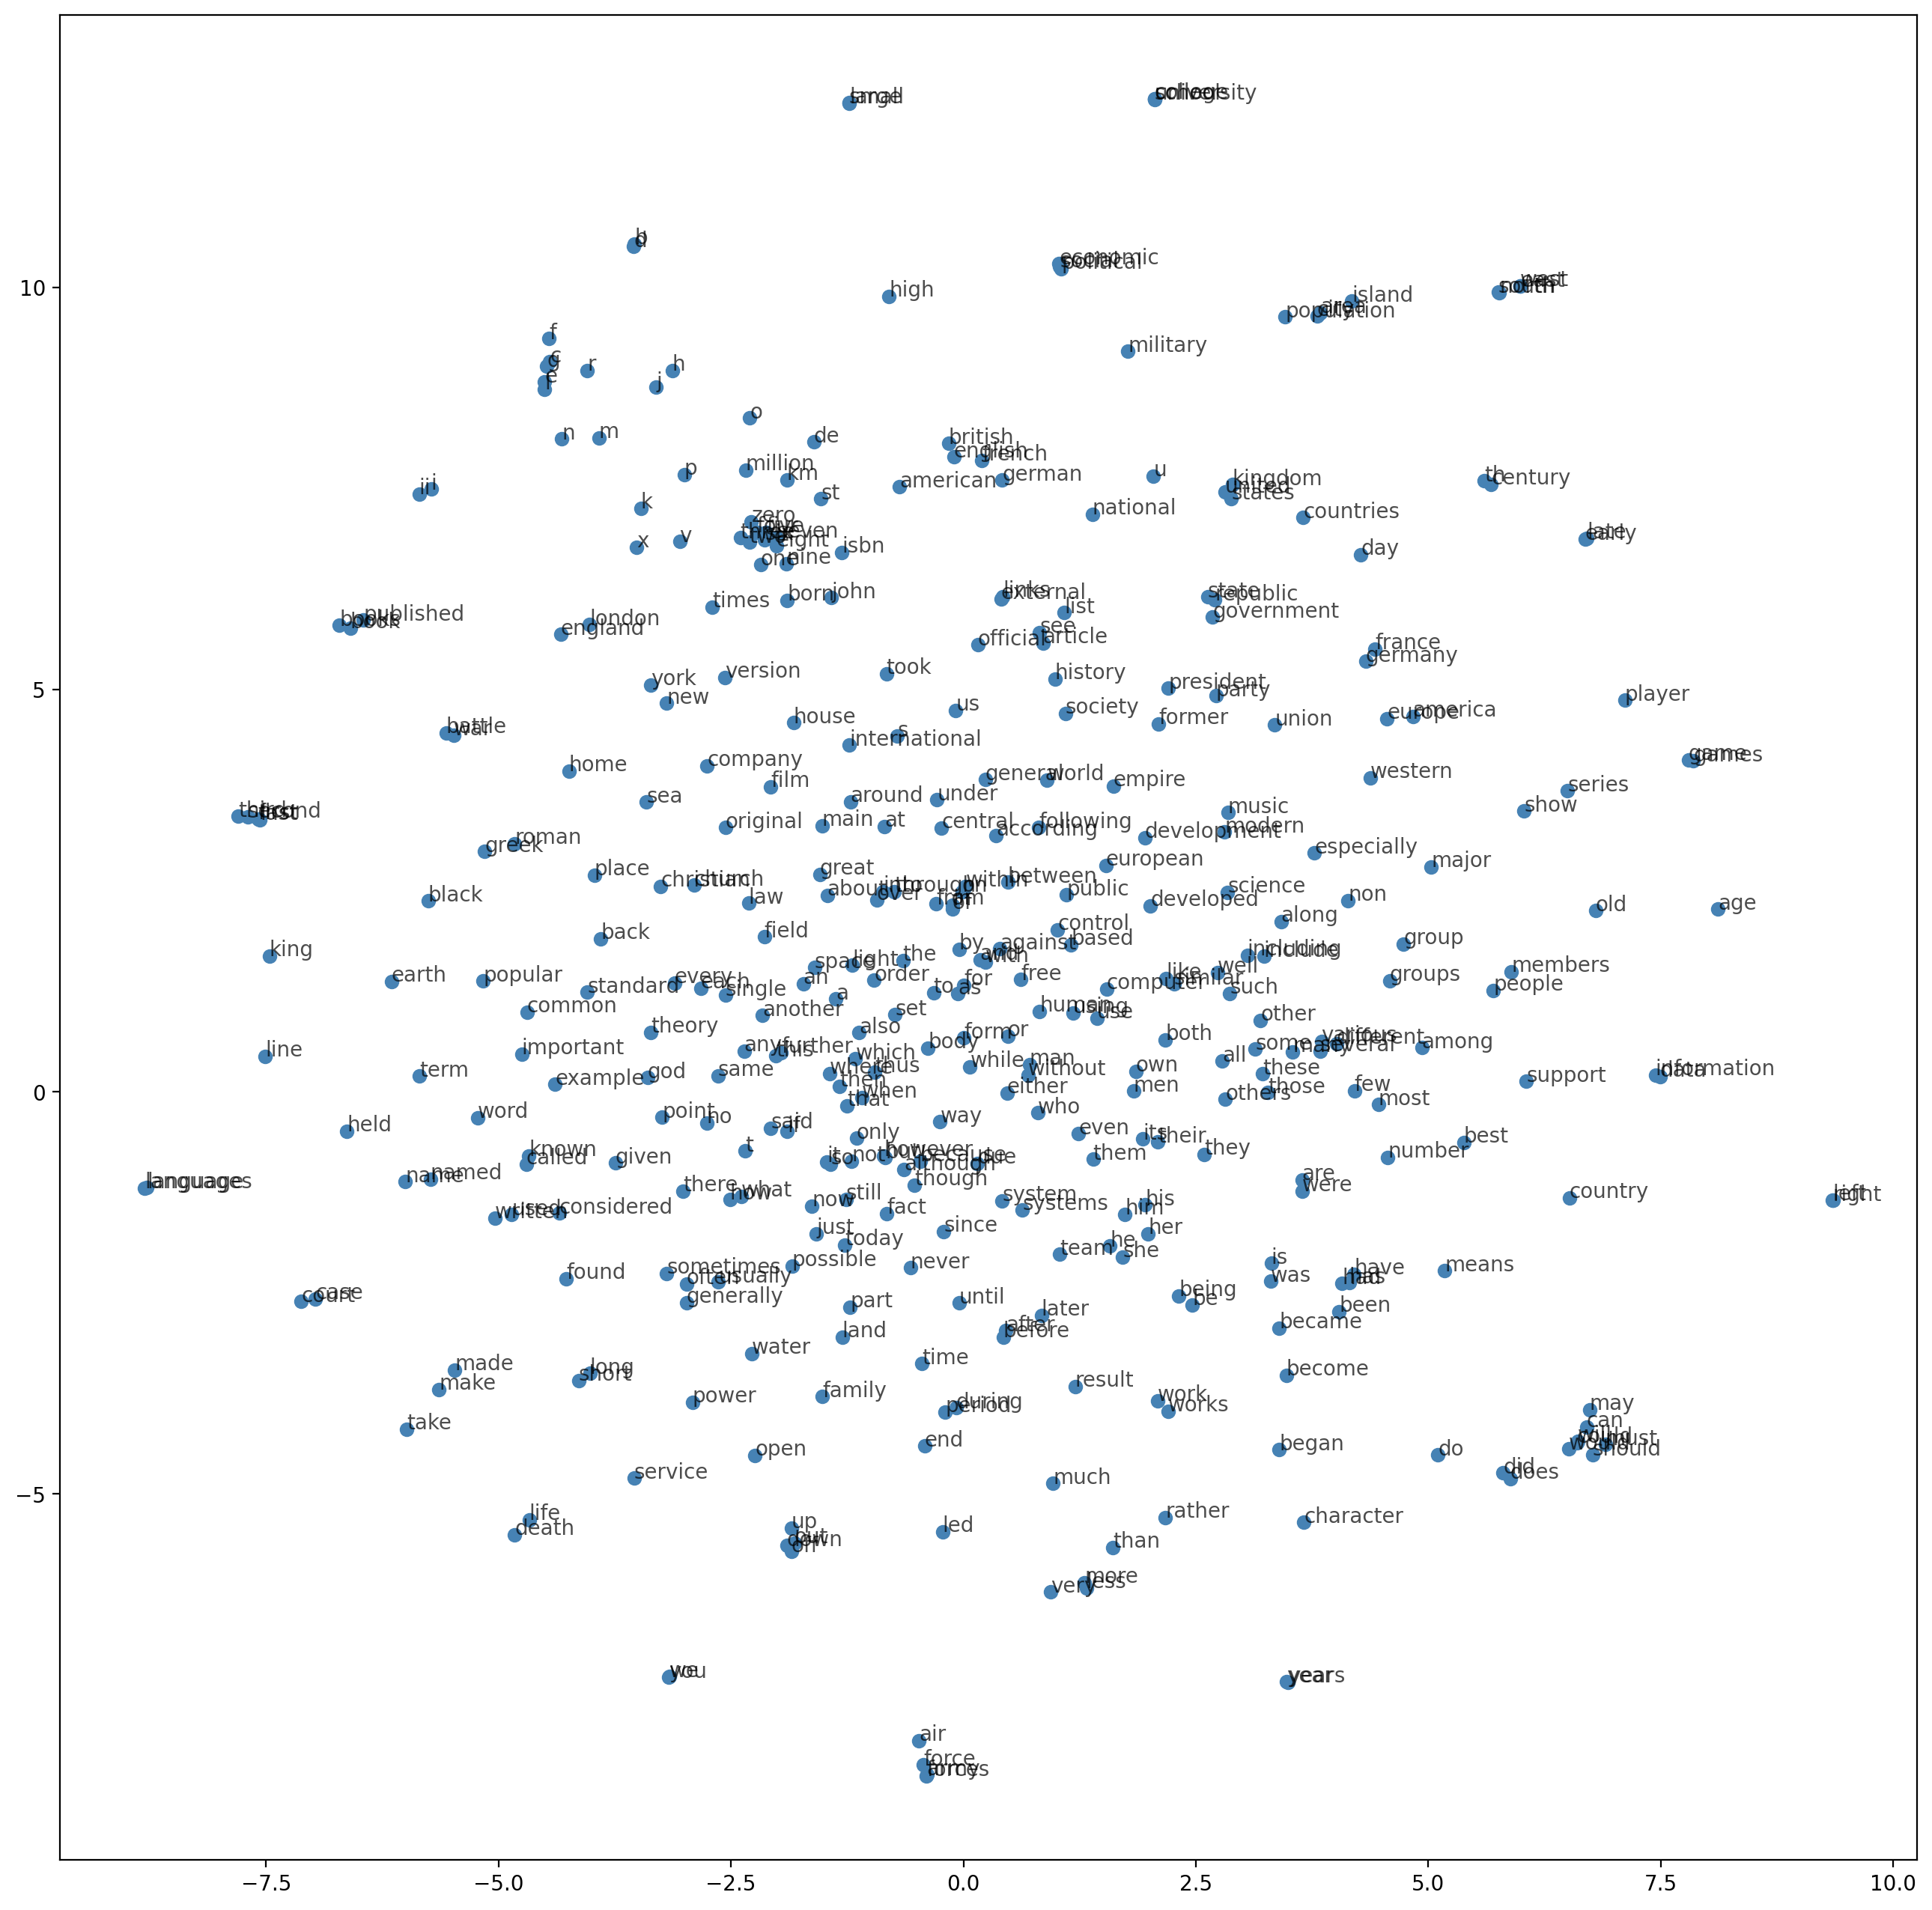

In [32]:
fig, ax = plt.subplots(figsize=(16, 16))
for idx in range(viz_words):
    plt.scatter(*embed_tsne[idx, :], color='steelblue')
    plt.annotate(idx2word[idx], (embed_tsne[idx, 0], embed_tsne[idx, 1]), alpha=0.7)